In [1]:
from brian2 import *
import numpy as np

np.random.seed(3)

start_scope()
delta_t = 0.1
sim_length = 3000
defaultclock.dt = delta_t*ms
### neuron model parameters ###
C = 200*pF
g_leak = 10*nS
tau = 20*ms
V_rest = -60*mV
reversal_P = 0*mV
reversal_B = -70*mV
reversal_A = -70*mV
V_th = -50*mV
V_reset = -60*mV

### synapse parameters ###
synaptic_delay = 1*ms

tau_syn_P = 2*ms
tau_syn_A = 4*ms
tau_syn_B = 1.5*ms

tau_D = 250*ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2*nS
p_PP = 0.01

g_PA = 6*nS
p_PA = 0.6

g_PB = 0.7*nS
p_PB = 0.5

g_AP = 0.2*nS
p_AP = 0.01

g_AA = 4*nS
p_AA = 0.6

g_AB = 8*nS
p_AB = 0.2

g_BP = 0.05*nS
p_BP = 0.2

g_BA = 7*nS
p_BA = 0.6

g_BB = 5*nS
p_BB =0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200*pA

# I_ext = I_BG + I_i


### equations ###
eqs = '''
I_ext : amp (shared)
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
I_syn_B = g_B*(v - reversal_B) : amp 
'''
@network_operation(dt=delta_t*ms, when='start')
def current_pulse():
       
       if 1500*ms <= defaultclock.t <= 1510*ms:
              group_B[0:99].I_ext = np.random.uniform(0,700)*pA
       else:
              group_B.I_ext = 200*pA
              group_A.I_ext = 200*pA
              group_P.I_ext = 200*pA

#d - 
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')



### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)


synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)


synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)



synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)


# to control depression
clamp_depr = 1
eqs_std_AB = '''
       g_ab : 1
       de_AB / dt = clamp_depr * (1. - e_AB) / tau_D : 1 (clock-driven)
       '''

synapse_AB = Synapses(group_B, group_A, model=eqs_std_AB, on_pre='''
                    g_B_post += g_AB*e_AB
                    e_AB = clip(e_AB - e_AB * eta_D, 0, 1)
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)


group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)


# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)

current_monitor = StateMonitor(group_P, 'I_syn_B', record=True)

statemon = StateMonitor(group_B, 'I_ext', record=True)
#eventmon = EventMonitor(group_B, ('pulse_on', 'I_i'), record=True)
network = Network(collect())

# Run the simulation
network.run(sim_length*ms)

/Users/maxnowa/Library/Caches/cython/brian_extensions/_cython_magic_35824ef86305507537a03081279e76b6.cpp:1298:14: fatal error: 'cstdlib' file not found
 1298 |     #include <cstdlib>
      |              ^~~~~~~~~
1 error generated.
WARNING    Cannot use Cython, a test compilation failed: command '/usr/bin/clang++' failed with exit code 1 (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    Variable I_ext is a shared v

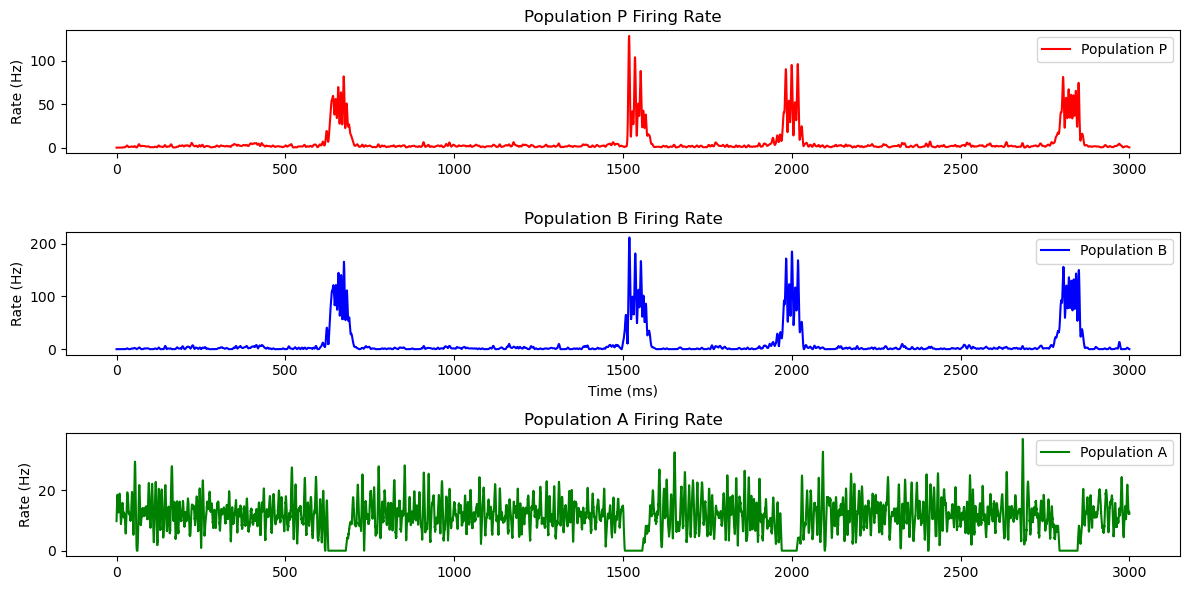

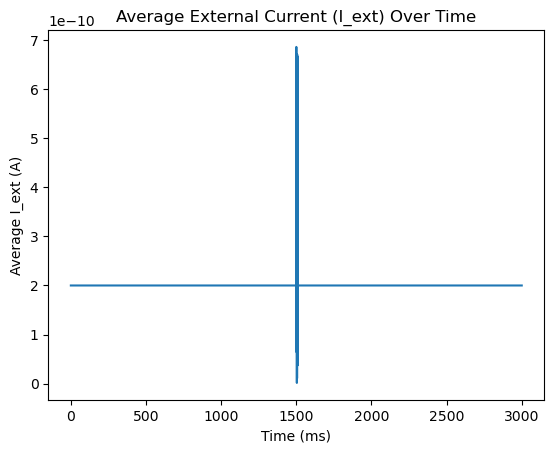

In [2]:
import matplotlib.pyplot as plt


# Plot population rates
plt.figure(figsize=(12, 6))

# Population P
plt.subplot(3, 1, 1)
plt.plot(pop_rate_P.t/ms, pop_rate_P.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population P', color="red")
plt.ylabel('Rate (Hz)')

plt.title('Population P Firing Rate')
plt.legend()


# Population B
plt.subplot(3, 1, 2)
plt.plot(pop_rate_B.t/ms, pop_rate_B.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population B', color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.title('Population B Firing Rate')
plt.legend()

# Population A
plt.subplot(3, 1, 3)
plt.plot(pop_rate_A.t/ms, pop_rate_A.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population A', color='green')
plt.ylabel('Rate (Hz)')

plt.title('Population A Firing Rate')
plt.legend()

plt.tight_layout()
plt.show()


# Calculate the average I_ext over time
#average_I_ext = statemon.I_ext.mean(axis=0)

# Calculate the average I_ext over time
average_I_ext = np.mean(statemon.I_ext, axis=0)


# Plot the average I_ext over time
plt.plot(statemon.t / ms, average_I_ext / amp)
plt.xlabel('Time (ms)')
plt.ylabel('Average I_ext (A)')
plt.title('Average External Current (I_ext) Over Time')

plt.show()



In [3]:
"""Detect peaks in data based on their amplitude and other features."""

from __future__ import division, print_function
import numpy as np

__author__ = "Marcos Duarte, https://github.com/demotu/BMC"
__version__ = "1.0.4"
__license__ = "MIT"


def detect_peaks(x, mph=None, mpd=1, threshold=0, edge='rising',
                 kpsh=False, valley=False, show=False, ax=None):
    """Detect peaks in data based on their amplitude and other features.
    Parameters
    ----------
    x : 1D array_like
        data.
    mph : {None, number}, optional (default = None)
        detect peaks that are greater than minimum peak height.
    mpd : positive integer, optional (default = 1)
        detect peaks that are at least separated by minimum peak distance (in
        number of data).
    threshold : positive number, optional (default = 0)
        detect peaks (valleys) that are greater (smaller) than `threshold`
        in relation to their immediate neighbors.
    edge : {None, 'rising', 'falling', 'both'}, optional (default = 'rising')
        for a flat peak, keep only the rising edge ('rising'), only the
        falling edge ('falling'), both edges ('both'), or don't detect a
        flat peak (None).
    kpsh : bool, optional (default = False)
        keep peaks with same height even if they are closer than `mpd`.
    valley : bool, optional (default = False)
        if True (1), detect valleys (local minima) instead of peaks.
    show : bool, optional (default = False)
        if True (1), plot data in matplotlib figure.
    ax : a matplotlib.axes.Axes instance, optional (default = None).
    Returns
    -------
    ind : 1D array_like
        indeces of the peaks in `x`.
    Notes
    -----
    The detection of valleys instead of peaks is performed internally by simply
    negating the data: `ind_valleys = detect_peaks(-x)`

    The function can handle NaN's
    See this IPython Notebook [1]_.
    References
    ----------
    .. [1] http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/DetectPeaks.ipynb
    Examples
    --------
    # >>> from detect_peaks import detect_peaks
    # >>> x = np.random.randn(100)
    # >>> x[60:81] = np.nan
    # >>> # detect all peaks and plot data
    # >>> ind = detect_peaks(x, show=True)
    # >>> print(ind)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # set minimum peak height = 0 and minimum peak distance = 20
    # >>> detect_peaks(x, mph=0, mpd=20, show=True)
    # >>> x = [0, 1, 0, 2, 0, 3, 0, 2, 0, 1, 0]
    # >>> # set minimum peak distance = 2
    # >>> detect_peaks(x, mpd=2, show=True)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # detection of valleys instead of peaks
    # >>> detect_peaks(x, mph=0, mpd=20, valley=True, show=True)
    # >>> x = [0, 1, 1, 0, 1, 1, 0]
    # >>> # detect both edges
    # >>> detect_peaks(x, edge='both', show=True)
    # >>> x = [-2, 1, -2, 2, 1, 1, 3, 0]
    # >>> # set threshold = 2
    # >>> detect_peaks(x, threshold = 2, show=True)
    """

    x = np.atleast_1d(x).astype('float64')
    if x.size < 3:
        return np.array([], dtype=int)
    if valley:
        x = -x
    # find indexes of all peaks
    dx = x[1:] - x[:-1]
    # handle NaN's
    indnan = np.where(np.isnan(x))[0]
    if indnan.size:
        x[indnan] = np.inf
        dx[np.where(np.isnan(dx))[0]] = np.inf
    ine, ire, ife = np.array([[], [], []], dtype=int)
    if not edge:
        ine = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) > 0))[0]
    else:
        if edge.lower() in ['rising', 'both']:
            ire = np.where((np.hstack((dx, 0)) <= 0) & (np.hstack((0, dx)) > 0))[0]
        if edge.lower() in ['falling', 'both']:
            ife = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) >= 0))[0]
    ind = np.unique(np.hstack((ine, ire, ife)))
    # handle NaN's
    if ind.size and indnan.size:
        # NaN's and values close to NaN's cannot be peaks
        ind = ind[np.in1d(ind, np.unique(np.hstack((indnan, indnan - 1, indnan + 1))), invert=True)]
    # first and last values of x cannot be peaks
    if ind.size and ind[0] == 0:
        ind = ind[1:]
    if ind.size and ind[-1] == x.size - 1:
        ind = ind[:-1]
    # remove peaks < minimum peak height
    if ind.size and mph is not None:
        ind = ind[x[ind] >= mph]
    # remove peaks - neighbors < threshold
    if ind.size and threshold > 0:
        dx = np.min(np.vstack([x[ind] - x[ind - 1], x[ind] - x[ind + 1]]), axis=0)
        ind = np.delete(ind, np.where(dx < threshold)[0])
    # detect small peaks closer than minimum peak distance
    if ind.size and mpd > 1:
        ind = ind[np.argsort(x[ind])][::-1]  # sort ind by peak height
        idel = np.zeros(ind.size, dtype=bool)
        for i in range(ind.size):
            if not idel[i]:
                # keep peaks with the same height if kpsh is True
                idel = idel | (ind >= ind[i] - mpd) & (ind <= ind[i] + mpd) \
                              & (x[ind[i]] > x[ind] if kpsh else True)
                idel[i] = 0  # Keep current peak
        # remove the small peaks and sort back the indexes by their occurrence
        ind = np.sort(ind[~idel])

    if show:
        if indnan.size:
            x[indnan] = np.nan
        if valley:
            x = -x
        _plot(x, mph, mpd, threshold, edge, valley, ax, ind)

    return ind


def _plot(x, mph, mpd, threshold, edge, valley, ax, ind):
    """Plot results of the detect_peaks function, see its help."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not available.')
    else:
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(8, 4))

        ax.plot(x, 'b', lw=1)
        if ind.size:
            label = 'valley' if valley else 'peak'
            label = label + 's' if ind.size > 1 else label
            ax.plot(ind, x[ind], '+', mfc=None, mec='r', mew=2, ms=8,
                    label='%d %s' % (ind.size, label))
            ax.legend(loc='best', framealpha=.5, numpoints=1)
        ax.set_xlim(-.02 * x.size, x.size * 1.02 - 1)
        ymin, ymax = x[np.isfinite(x)].min(), x[np.isfinite(x)].max()
        yrange = ymax - ymin if ymax > ymin else 1
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)
        ax.set_xlabel('Data #', fontsize=14)
        ax.set_ylabel('Amplitude', fontsize=14)
        mode = 'Valley detection' if valley else 'Peak detection'
        ax.set_title("%s (mph=%s, mpd=%d, threshold=%s, edge='%s')"
                     % (mode, str(mph), mpd, str(threshold), edge))

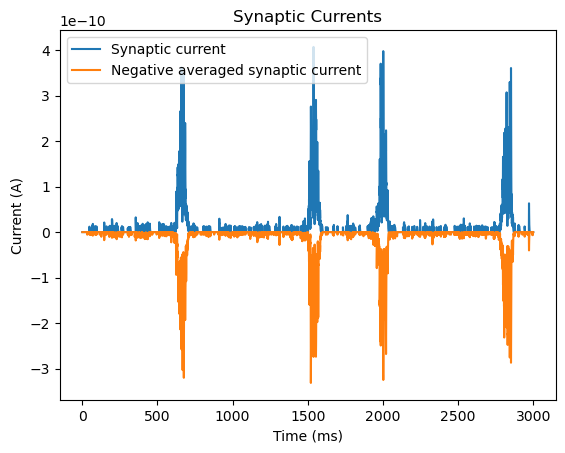

In [4]:
from scipy.signal import butter, filtfilt

plt.plot(current_monitor.t/ms, current_monitor.I_syn_B[0]/amp, label="Synaptic current")

averaged = -np.average(current_monitor.I_syn_B, axis=0)

plt.plot(current_monitor.t/ms, averaged/amp, label="Negative averaged synaptic current")
plt.title('Synaptic Currents')
plt.xlabel('Time (ms)')
plt.ylabel('Current (A)')
plt.legend()

def create_butter_bandpass(lowcut, highcut, fs, order=2, btype='band'):
    """create a butterworth digital filter with given order"""
    # normalize freq with Nyquist freq (to be in [0,1])
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if btype == 'band':
        b, a = butter(order, [low, high], btype=btype, analog=False)
    elif btype == 'low':
        b, a = butter(order, high, btype=btype, analog=False)
    else:
        b = 0
        a = 0
    return b, a

b, a = create_butter_bandpass(90, 180, 1e4, 2, btype="band")
band_pass = filtfilt(b, a, -averaged)

b2, a2 = create_butter_bandpass(0, 5, 1e4, 2, btype="low")
low_pass = filtfilt(b2, a2, -averaged)



Text(0, 0.5, 'Current (A)')

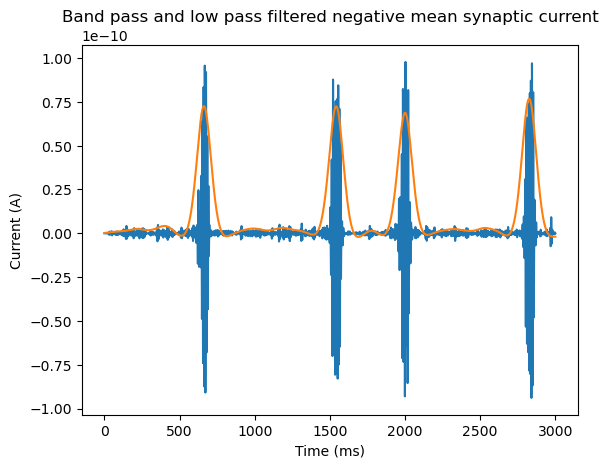

In [5]:
# plot band pass and low pass filtered negative mean synaptic current


plt.plot(current_monitor.t/ms, band_pass/amp)

plt.plot(current_monitor.t/ms, low_pass/amp)
plt.title("Band pass and low pass filtered negative mean synaptic current")
plt.xlabel("Time (ms)")
plt.ylabel("Current (A)")

[7.25355098e-11 7.24302717e-11 6.87901973e-11 7.67464620e-11]


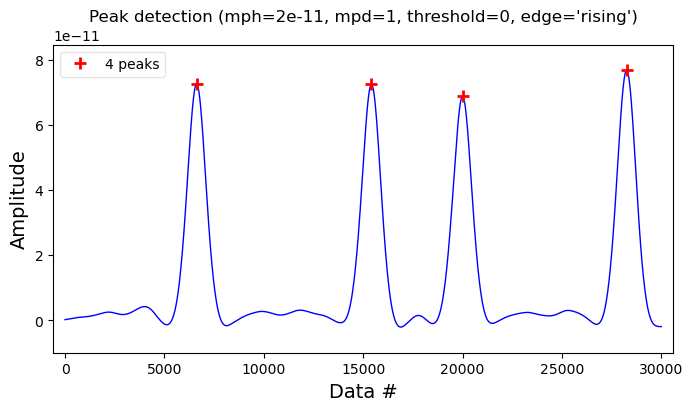

In [6]:
indx = detect_peaks(low_pass, mph=2e-11, mpd=1, threshold=0, edge='rising', valley=False, show=True)


peak_values = low_pass[indx]
print(peak_values)


In [49]:
def find_onset(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    """Find the onset of a sequence of data relative to a set of peaks"""
    baselines = []
    for peak_index in indices:
        # find the baseline
        baseline_start = int(peak_index-baseline_window_low/dt)
        baseline_end = int(peak_index-baseline_window_high/dt)
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)
    global_baseline = np.mean(baselines)

    
    # fwhm = [seq[seq > np.mean(p, global_baseline)] for p in peaks]
    points = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])
        local_seq = seq[indices[idx]-int(100/dt):indices[idx]]
        fwhm_point = seq[np.where(local_seq > fwhm)][0]
        points.append(fwhm_point)
    print(points)

onset = find_onset(low_pass, peak_values, indx, 200, 100, delta_t)
     
        
    





[6.98107986124589e-13, 6.90531141973685e-13, 6.883549587013881e-13, 6.872650313377739e-13]
[[ 1.96936260e-13  1.97749955e-13  1.98565317e-13 ... -1.94171822e-12
  -1.94172073e-12 -1.94172278e-12]]
